Preprocessing

In [15]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import adjusted_rand_score


Loading Data

In [3]:
cols = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
    'restecg', 'thalach', 'exang', 'oldpeak',
    'slope', 'ca', 'thal', 'target'
]

df = pd.read_csv("processed.cleveland.data", header=None, names=cols)   # change filename if needed

df = df.replace('?', np.nan)

df = df.dropna()

df = df.apply(pd.to_numeric)

df['target'] = (df['target'] > 0).astype(int)

print(df.head())
print(df['target'].value_counts())

print("Original Shape:", df.shape)   

print("\nFirst 5 Rows:")
print(df.head())

print("\nData Types:")
print(df.dtypes)

    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       1  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  
target
0    160
1    137
Name: count, dtype: int64
Original Shape: (297, 14)

First 5 Rows:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0

Handling missing values

In [4]:
df = df.replace('?', np.nan)

missing_cols = df.columns[df.isna().any()]

print("\nColumns with missing values:")
for col in missing_cols:
    print(f"{col}: {df[col].isna().sum()} missing")

rows_with_missing = df.isna().any(axis=1).sum()
print("\nRows containing missing values:", rows_with_missing)

df = df.dropna()

print("Shape after dropping missing rows:", df.shape)
print("Final retained row count:", len(df))


Columns with missing values:

Rows containing missing values: 0
Shape after dropping missing rows: (297, 14)
Final retained row count: 297


In [5]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col])


TARGET CLASS DISTRIBUTION

In [6]:
target_counts = df['target'].value_counts().sort_index()
target_percent = df['target'].value_counts(normalize=True).sort_index() * 100

print("\nTarget Class Distribution:")
for cls in target_counts.index:
    print(f"Class {cls}: {target_counts[cls]} ({target_percent[cls]:.2f}%)")

# Brief balance check
minority_ratio = target_counts.min() / target_counts.max()

if minority_ratio < 0.80:
    print("\nDataset is moderately imbalanced.")
    use_smote = True
else:
    print("\nDataset is reasonably balanced.")
    use_smote = False


Target Class Distribution:
Class 0: 160 (53.87%)
Class 1: 137 (46.13%)

Dataset is reasonably balanced.


TRAIN / TEST SPLIT (before scaling)

In [7]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape :", X_test.shape)



Train shape: (237, 13)
Test shape : (60, 13)


ENCODING + STANDARDIZATION

In [8]:
categorical_cols = ['cp', 'restecg', 'slope', 'thal']
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

# One-hot encode
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align test columns with training columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Standardize continuous columns (fit only on training set)
scaler = StandardScaler()

X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

APPLY SMOTE ONLY ON TRAINING SPLIT

In [9]:
if use_smote:
    smote = SMOTE(random_state=42)
    X_train, y_train = smote.fit_resample(X_train, y_train)

    print("\nAfter SMOTE:")
    print(pd.Series(y_train).value_counts())

CORRELATION HEATMAP (before encoding)

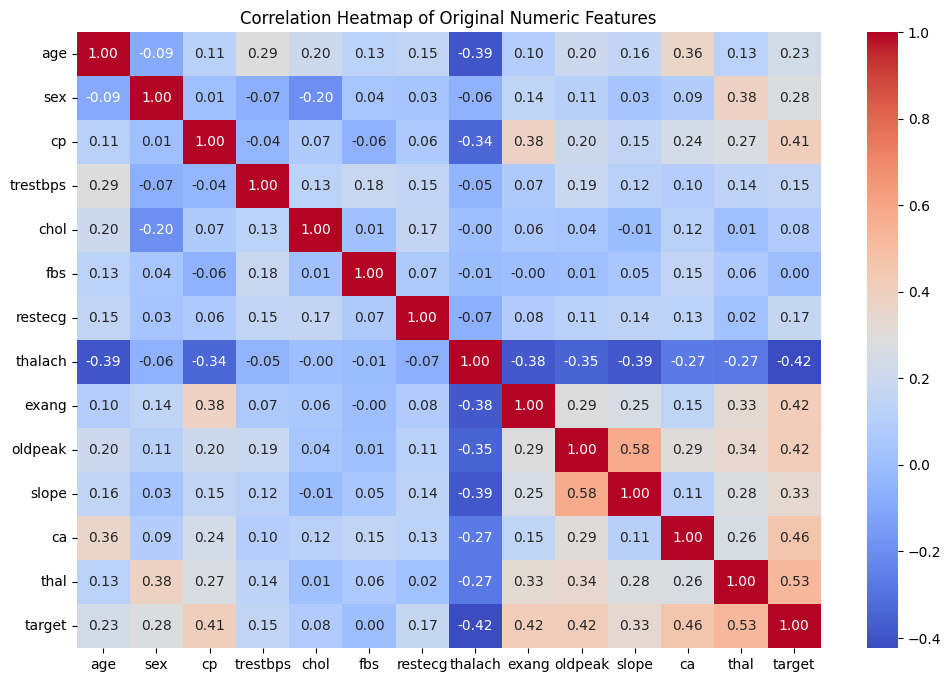

In [10]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Original Numeric Features")
plt.show()

TOP 3 STRONGEST CORRELATIONS

In [11]:
corr_matrix = numeric_df.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

top_pairs = upper.unstack().dropna().sort_values(ascending=False)

print("\nTop 3 Strongest Correlated Feature Pairs:")
for i in range(3):
    pair = top_pairs.index[i]
    value = top_pairs.iloc[i]
    print(f"{pair[0]} - {pair[1]} : {value:.3f}")


Top 3 Strongest Correlated Feature Pairs:
slope - oldpeak : 0.579
target - thal : 0.527
target - ca : 0.463


Part A

A1 

FULL FEATURE MATRIX (without target)

In [17]:
X_full = df.drop('target', axis=1)
y_true = df['target']

# Standardize full feature matrix
scaler_unsup = StandardScaler()
X_scaled = scaler_unsup.fit_transform(X_full)

K-MEANS FOR k = 2..8

In [18]:
k_values = range(2, 9)
wcss = []
sil_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

chosing K 

In [19]:
best_k = k_values[np.argmax(sil_scores)]

print("WCSS values:")
for k, val in zip(k_values, wcss):
    print(f"k={k}: {val:.2f}")

print("\nSilhouette Scores:")
for k, val in zip(k_values, sil_scores):
    print(f"k={k}: {val:.4f}")

print(f"\nChosen k = {best_k}")

WCSS values:
k=2: 3193.45
k=3: 2931.15
k=4: 2743.77
k=5: 2609.80
k=6: 2507.28
k=7: 2404.55
k=8: 2318.45

Silhouette Scores:
k=2: 0.1751
k=3: 0.1298
k=4: 0.1304
k=5: 0.1127
k=6: 0.1137
k=7: 0.1013
k=8: 0.1060

Chosen k = 2


Plot WCSS + Silhouette

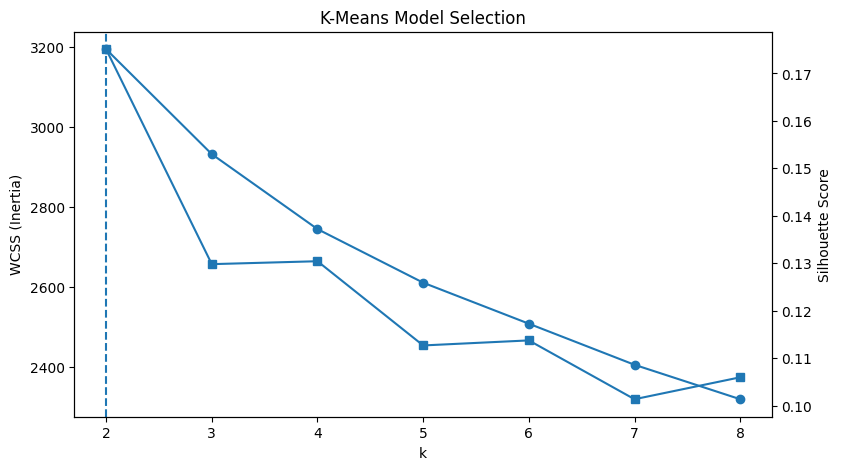

In [20]:
fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(k_values, wcss, marker='o')
ax1.set_xlabel("k")
ax1.set_ylabel("WCSS (Inertia)")

ax2 = ax1.twinx()
ax2.plot(k_values, sil_scores, marker='s')
ax2.set_ylabel("Silhouette Score")

ax1.axvline(best_k, linestyle='--')

plt.title("K-Means Model Selection")
plt.show()


FINAL K-MEANS WITH CHOSEN k

In [21]:
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

PCA TO 2D

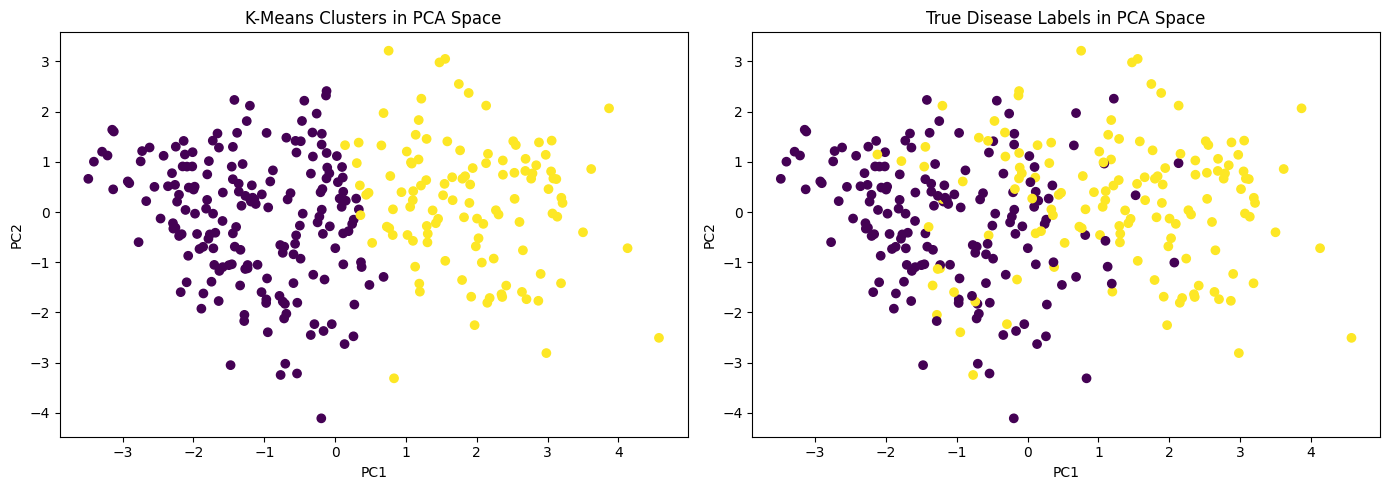

In [22]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cluster labels
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels)
axes[0].set_title("K-Means Clusters in PCA Space")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

# True labels
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_true)
axes[1].set_title("True Disease Labels in PCA Space")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.show()


CLUSTER SUMMARY TABLE

In [23]:
summary_df = X_full.copy()
summary_df['target'] = y_true
summary_df['cluster'] = cluster_labels

cluster_summary = summary_df.groupby('cluster').agg(
    cluster_size=('target', 'count'),
    heart_disease_proportion=('target', 'mean'),
    thalach_mean=('thalach', 'mean'),
    oldpeak_mean=('oldpeak', 'mean'),
    cp_mean=('cp', 'mean')
)

print("\nCluster Summary:")
print(cluster_summary)


Cluster Summary:
         cluster_size  heart_disease_proportion  thalach_mean  oldpeak_mean  \
cluster                                                                       
0                 184                  0.201087    159.880435      0.542935   
1                 113                  0.884956    132.858407      1.890265   

          cp_mean  
cluster            
0        2.782609  
1        3.769912  


SIMPLE CLINICAL PROFILES

In [24]:
for c in sorted(summary_df['cluster'].unique()):
    subset = summary_df[summary_df['cluster'] == c]

    print(f"\nCluster {c} profile:")
    print(f"Size = {len(subset)}")
    print(f"Heart disease proportion = {subset['target'].mean():.2f}")
    print(f"Mean thalach = {subset['thalach'].mean():.2f}")
    print(f"Mean oldpeak = {subset['oldpeak'].mean():.2f}")
    print(f"Mean cp = {subset['cp'].mean():.2f}")



Cluster 0 profile:
Size = 184
Heart disease proportion = 0.20
Mean thalach = 159.88
Mean oldpeak = 0.54
Mean cp = 2.78

Cluster 1 profile:
Size = 113
Heart disease proportion = 0.88
Mean thalach = 132.86
Mean oldpeak = 1.89
Mean cp = 3.77


ADJUSTED RAND INDEX

In [25]:
ari = adjusted_rand_score(y_true, cluster_labels)

print(f"\nAdjusted Rand Index (ARI): {ari:.4f}")


Adjusted Rand Index (ARI): 0.4380


A2